# 이상지질혈증 예측 - XGBoost Feature Engineering 실험

- 타겟: `이상지질혈증유병` (0: 없음 / 1: 있음)
- 모델: XGBoost (Optuna 최적 파라미터 고정)
- 데이터: hn_all_preprocessed_v2.csv
- Threshold: 0.45 고정
- 목적: **피처 추가·제거 실험으로 성능 변화 확인**
- 검증: Stratified 5-Fold CV

In [30]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── 경로 설정 (상대 경로) ──────────────────────────────────
CURRENT_DIR = os.path.dirname(os.path.abspath(""))
BASE_DIR = os.path.join(CURRENT_DIR, "..")
DATA_PATH = os.path.join(BASE_DIR, "data", "hn_all_preprocessed_v2.csv")
FEATURES_DIR = os.path.join(BASE_DIR, "features")
NPY_DIR = os.path.join(BASE_DIR, "outputs", "oof")
sys.path.insert(0, FEATURES_DIR)

RANDOM_STATE = 42
THRESHOLD = 0.45

## 1. 데이터 로드

In [31]:
df = pd.read_csv(DATA_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (19765, 31)


## 2. ✏️ Feature Engineering 설정

> **실험 방법:** 추가하고 싶은 피처 함수의 주석을 해제하세요.
> 순서 중요: `add_age_bin` → `add_family_sum` → 나머지

In [32]:
# ── 피처 엔지니어링 함수 import ──────────────────────────────

# ── 적용할 피처 선택 (주석 해제 = 적용) ──────────────────────
# df = add_age_bin(df)                    # ✅ 나이_구간
# df = add_family_sum(df,                 # ✅ 가족력_합계
#                     hypertension=True,
#                     diabetes=True,
#                     dyslipidemia=True)
# df = add_bmi_bin(df)                    # ✅ BMI_구간 (이상지질혈증 우선 적용)
# df = add_alcohol_load(df)             # ❌ 음주_총부하 (필요 시 해제)
# df = add_exercise_total(df)           # ❌ 총운동일수 (필요 시 해제)
# df = add_body_features(df)            # ❌ 체형 복합 (이상지질혈증 특화, 필요 시 해제)
# df = add_age_family_interaction(df,   # ❌ 나이×가족력 (필요 시 해제)
#                                 hypertension=False, diabetes=False)

print(f"\n피처 엔지니어링 완료 | shape: {df.shape}")


피처 엔지니어링 완료 | shape: (19765, 31)


## 3. 피처 / 타겟 분리

In [33]:
TARGET = "이상지질혈증유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos

print(f"샘플 수: {len(y)}  |  정상: {neg}  |  이상지질혈증: {pos}")
print(f"사용 피처 수: {X.shape[1]}")
print(f"피처 목록: {list(X.columns)}")

샘플 수: 19175  |  정상: 13732  |  이상지질혈증: 5443
사용 피처 수: 28
피처 목록: ['성별', '나이', '현재흡연', '걷기일수', '근력운동일수', '고혈압가족력_부', '고혈압가족력_모', '고혈압가족력_형제', '고지혈증가족력_부', '고지혈증가족력_모', '고지혈증가족력_형제', '당뇨가족력_부', '당뇨가족력_모', '당뇨가족력_형제', '키', '체중', 'BMI', '직업_관리전문', '직업_사무', '직업_서비스판매', '직업_농림어업', '직업_기능노무', '직업_주부학생', '직업_무직', '직업_작업미상', '과거음주_현재금주', '음주빈도_enc', '음주량_enc']


## 4. Optuna 최적 파라미터 설정

In [34]:
best_params = {
    "n_estimators": 487,
    "learning_rate": 0.08927180304353628,
    "max_depth": 7,
    "min_child_weight": 6,
    "subsample": 0.6624074561769746,
    "colsample_bytree": 0.662397808134481,
    "gamma": 0.05808361216819946,
    "reg_alpha": 0.8661761457749352,
    "reg_lambda": 2.002787529358022,
    "scale_pos_weight": ratio,
    "eval_metric": "auc",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0,
}
print("파라미터 설정 완료")

파라미터 설정 완료


## 5. Stratified 5-Fold CV

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= THRESHOLD).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.7778 | Recall: 0.8392 | F1: 0.5797 | best_iter: 71
  Fold 2 | AUC: 0.7985 | Recall: 0.8465 | F1: 0.5923 | best_iter: 58
  Fold 3 | AUC: 0.7850 | Recall: 0.8283 | F1: 0.5789 | best_iter: 83
  Fold 4 | AUC: 0.7887 | Recall: 0.8393 | F1: 0.5827 | best_iter: 33
  Fold 5 | AUC: 0.7851 | Recall: 0.8549 | F1: 0.5892 | best_iter: 47
  평균   | AUC: 0.7870±0.0075 | Recall: 0.8416±0.0099 | F1: 0.5846±0.0059


## 6. OOF proba 저장 (.npy)

In [36]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HL_xgboost_fe.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/model/../outputs/oof/oof_proba_HL_xgboost_fe.npy
로드 확인: shape=(19175, 2), 일치=True


## 7. OOF 성능 & 기준 모델 비교

In [37]:
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)

oof_auc = roc_auc_score(y, oof_proba)
oof_rec = recall_score(y, pred_oof)
oof_prec = precision_score(y, pred_oof)
oof_f1 = f1_score(y, pred_oof)
oof_acc = float((pred_oof == y).mean())

# 기준 모델 (FE 없음, Optuna)
BASE = {"auc": 0.7898, "recall": 0.8556, "precision": 0.4303, "f1": 0.5726, "acc": 0.6701, "fp": 1765, "fn": 225}

print("=" * 55)
print(f"  {'지표':<12}  {'기준 모델':>12}  {'FE 적용':>10}  변화")
print("=" * 55)
for label, base_v, cur_v in [
    ("AUC-ROC", BASE["auc"], oof_auc),
    ("Recall", BASE["recall"], oof_rec),
    ("Precision", BASE["precision"], oof_prec),
    ("F1-score", BASE["f1"], oof_f1),
    ("Accuracy", BASE["acc"], oof_acc),
]:
    d = cur_v - base_v
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {label:<12}  {base_v:>12.4f}  {cur_v:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {BASE['fp']:>12}  {cm[0, 1]:>10}  {'▼' if cm[0, 1] < BASE['fp'] else '▲'} {abs(cm[0, 1] - BASE['fp'])}"
)
print(
    f"  {'FN':<12}  {BASE['fn']:>12}  {cm[1, 0]:>10}  {'▼' if cm[1, 0] < BASE['fn'] else '▲'} {abs(cm[1, 0] - BASE['fn'])}"
)
print("=" * 55)
print("\n[분류 리포트]")
print(classification_report(y, pred_oof, target_names=["정상(0)", "이상지질혈증(1)"]))

  지표                   기준 모델       FE 적용  변화
  AUC-ROC             0.7898      0.7864  ▼ 0.0034
  Recall              0.8556      0.8416  ▼ 0.0140
  Precision           0.4303      0.4478  ▲ 0.0175
  F1-score            0.5726      0.5846  ▲ 0.0120
  Accuracy            0.6701      0.6604  ▼ 0.0097
  FP                    1765        5649  ▲ 3884
  FN                     225         862  ▲ 637

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.90      0.59      0.71     13732
   이상지질혈증(1)       0.45      0.84      0.58      5443

    accuracy                           0.66     19175
   macro avg       0.68      0.72      0.65     19175
weighted avg       0.77      0.66      0.68     19175



## 8. Confusion Matrix

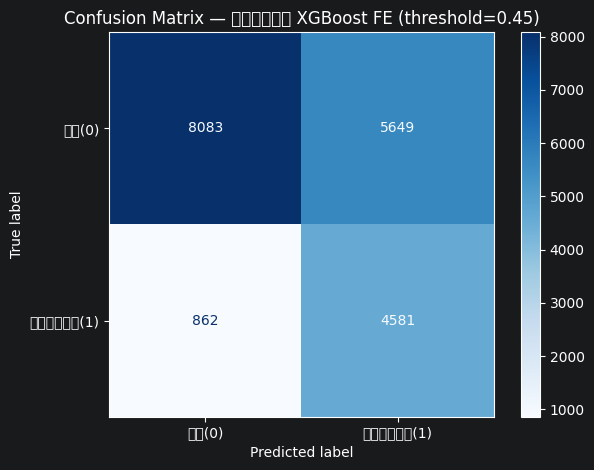

In [38]:
disp = ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "이상지질혈증(1)"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — 이상지질혈증 XGBoost FE (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

## 9. Feature Importance (XGBoost, 5-Fold 평균)

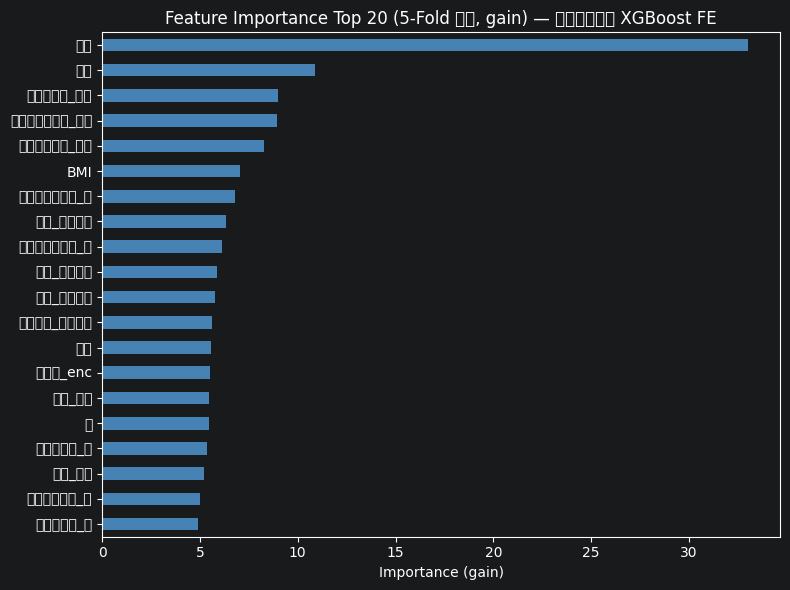

   1. 나이: 33.0
   2. 성별: 10.9
   3. 당뇨가족력_형제: 9.0
   4. 고지혈증가족력_형제: 8.9
   5. 고혈압가족력_형제: 8.3
   6. BMI: 7.0
   7. 고지혈증가족력_모: 6.8
   8. 직업_주부학생: 6.3
   9. 고지혈증가족력_부: 6.1
  10. 직업_관리전문: 5.9
  11. 직업_농림어업: 5.8
  12. 과거음주_현재금주: 5.6
  13. 체중: 5.6
  14. 음주량_enc: 5.5
  15. 직업_사무: 5.5
  16. 키: 5.4
  17. 당뇨가족력_모: 5.4
  18. 직업_무직: 5.2
  19. 고혈압가족력_부: 5.0
  20. 당뇨가족력_부: 4.9


In [39]:
fi_list = []
for fold, (tr_idx, val_idx) in enumerate(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y), 1
):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    m = xgb.XGBClassifier(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    gain = pd.Series(m.get_booster().get_score(importance_type="gain"))
    gain = gain.reindex(X.columns, fill_value=0)
    fi_list.append(gain)

fi = pd.DataFrame(fi_list).mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
fi.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("Feature Importance Top 20 (5-Fold 평균, gain) — 이상지질혈증 XGBoost FE")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()
for i, (feat, imp) in enumerate(fi.head(20).items(), 1):
    print(f"  {i:2d}. {feat}: {imp:.1f}")

## 10. SHAP 분석 (OOF 전체 기준)

SHAP Fold 1 완료
SHAP Fold 2 완료
SHAP Fold 3 완료
SHAP Fold 4 완료
SHAP Fold 5 완료


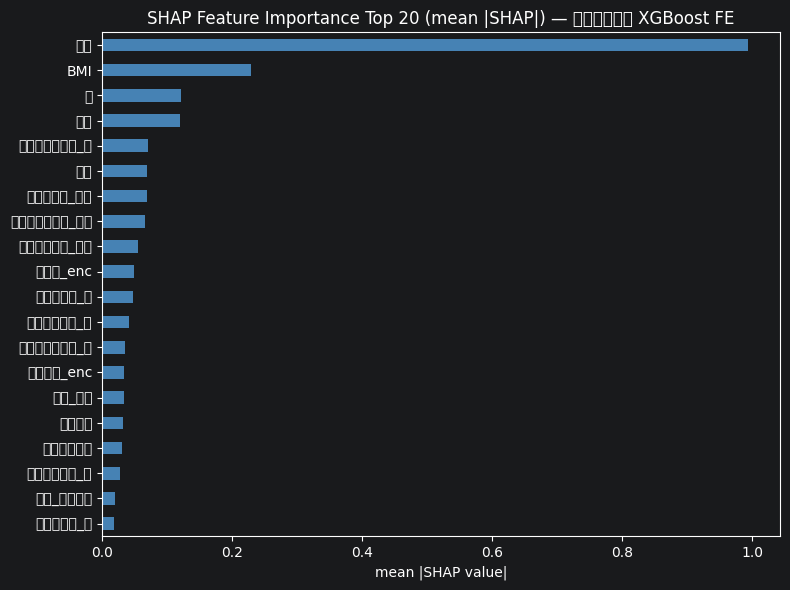

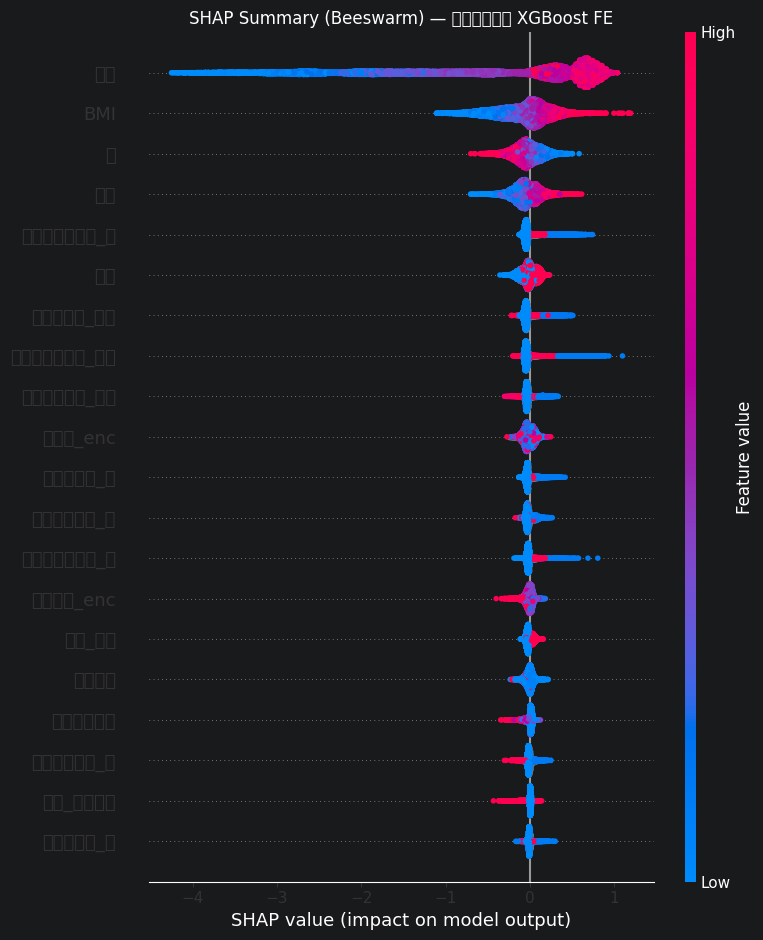

[SHAP Top 15]
   1. 나이: 0.9929
   2. BMI: 0.2289
   3. 키: 0.1217
   4. 체중: 0.1205
   5. 고지혈증가족력_모: 0.0702
   6. 성별: 0.0695
   7. 당뇨가족력_형제: 0.0689
   8. 고지혈증가족력_형제: 0.0657
   9. 고혈압가족력_형제: 0.0549
  10. 음주량_enc: 0.0492
  11. 당뇨가족력_모: 0.0478
  12. 고혈압가족력_모: 0.0420
  13. 고지혈증가족력_부: 0.0357
  14. 음주빈도_enc: 0.0344
  15. 직업_무직: 0.0332


In [40]:
import shap

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
shap_values = np.zeros(X.shape)

for fold, (tr_idx, val_idx) in enumerate(skf2.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    m = xgb.XGBClassifier(**best_params)
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    explainer = shap.TreeExplainer(m)
    shap_values[val_idx] = explainer.shap_values(X_val)
    print(f"SHAP Fold {fold} 완료")

mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

# SHAP Bar
plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind="barh", color="steelblue")
plt.title("SHAP Feature Importance Top 20 (mean |SHAP|) — 이상지질혈증 XGBoost FE")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

# SHAP Beeswarm
shap.summary_plot(shap_values, X, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary (Beeswarm) — 이상지질혈증 XGBoost FE", fontsize=12)
plt.tight_layout()
plt.show()

print("[SHAP Top 15]")
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    print(f"  {i:2d}. {feat}: {val:.4f}")

## 11. DB 로그 저장

In [42]:
sys.path.insert(0, os.path.join(BASE_DIR))
from model_logger import ModelLogger

logger = ModelLogger(os.path.join(BASE_DIR, "model_result.db"))

base_cols = pd.read_csv(DATA_PATH).columns.tolist()
fe_cols = [c for c in X.columns if c not in base_cols]
fe_note = f"FE 적용: {fe_cols}" if fe_cols else "FE 없음"

run_id = logger.log_run(
    target_var="이상지질혈증",
    model_name="XGBoost",
    stage="fe_exp",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "max_depth": best_params["max_depth"],
        "n_estimators": best_params["n_estimators"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "min_child_weight": best_params["min_child_weight"],
        "subsample": best_params["subsample"],
        "colsample_bytree": best_params["colsample_bytree"],
        "gamma": best_params["gamma"],
        "reg_alpha": best_params["reg_alpha"],
        "reg_lambda": best_params["reg_lambda"],
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": oof_acc,
        "recall": oof_rec,
        "precision": oof_prec,
        "f1_score": oof_f1,
        "auc_roc": oof_auc,
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=gain.head(15).to_dict(),
    note=fe_note,
)
print(f"저장 완료 → run_id: {run_id}  |  {fe_note}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=35 | 이상지질혈증 XGBoost (fe_exp)
저장 완료 → run_id: 35  |  FE 없음
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
     35 2026-05-18 21:03:29     이상지질혈증    XGBoost         fe_exp 0.786431 0.841631   0.447801  0.584572  0.660443
     34 2026-05-18 20:59:32         당뇨   CatBoost         fe_exp 0.837461 0.802233   0.461519  0.585947  0.732238
     33 2026-05-18 20:57:17        고혈압   CatBoost         fe_exp 0.856212 0.832085   0.585538  0.687373  0.756234
     32 2026-05-18 20:52:57        고혈압   CatBoost         fe_exp 0.856212 0.832085   0.585538  0.687373  0.756234
     31 2026-05-18 20:52:56         당뇨   CatBoost         fe_exp 0.837461 0.802233   0.461519  0.585947  0.732238
     30 2026-05-18 20:52:45     이상지질혈증    XGBoost         fe_exp 0.786431 0.841631   0.447801  0.584572  0.660443
     29 2026-05-18 20:39:58         당뇨   CatBoost         fe_exp 0.817464 0.810393   0.426875  0.559194  0.698261
 